# **Risk control of a binary text classifier**

This example demonstrates how to use risk control methods from the MAPIE library for binary text classification, here we use a dataset of SMS messages labeled as spam or not spam. In addition to the classification we want the model to abstain from making a decision when it is uncertain. Our aim is to control the risks associated with predictions for both classes, as well as the abstention rate. We study several ways of controlling these risks :


1. Classifier : Pool of LLMs
    - with a surrogate model
    - with a score like

2. Classifier : Naive Bayes 


## imports and utils

In [1]:
# should use mapie_notebooks environment but sentence-transformer is not included : 
#! pip install sentence-transformer

In [2]:
import io
import zipfile
import requests

import pandas as pd
import numpy as np
from numpy.typing import NDArray

from sentence_transformers import SentenceTransformer

from mapie.risk_control import (
    BinaryClassificationController,
    negative_predictive_value,
    positive_predictive_value,
)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, precision_score
from sklearn.preprocessing import StandardScaler, minmax_scale
from sklearn.svm import SVC

from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

In [3]:
RANDOM_STATE = 20

In [4]:
def transform_y(y):
    """Transform y (= label) data from str to int"""
    y = y.values.ravel()
    y_transformed = np.where(y == "spam", 1, 0)
    return y_transformed


def perf(risk, y_true, y_pred):
    val, _ = risk.get_value_and_effective_sample_size(y_true, y_pred)
    return 1 - val if risk.higher_is_better else val


def compute_risks(y_true, y_pred, abstention_rate_compute=False):
    if abstention_rate_compute:
        return {
            "positive_predictive_value": perf(positive_predictive_value, y_true, y_pred),
            "negative_predictive_value": perf(negative_predictive_value, y_true, y_pred),
            "abstention_rate": perf(abstention_rate, y_true, y_pred),
        }
    else:
        return {
                "positive_predictive_value": perf(positive_predictive_value, y_true, y_pred),
                "negative_predictive_value": perf(negative_predictive_value, y_true, y_pred)
            }

def confusion_matrix(y_true, y_pred):
    cm = np.array([
        [np.sum((y_true == 0) & (y_pred == 0)), np.sum((y_true == 0) & (y_pred == 1))],
        [np.sum((y_true == 1) & (y_pred == 0)), np.sum((y_true == 1) & (y_pred == 1))]
    ])
    return cm


In [5]:
def plot_valid_thresholds_and_risk(risk_matrix, risk_name, n_lambdas, lambda_1_values, lambda_2_values):

    # Build valid thresholds mask
    valid_matrix = np.zeros((n_lambdas, n_lambdas), dtype=int)
    for l1, l2 in bcc.valid_predict_params:
        row = np.argmin(np.abs(lambda_1_values - l1))
        col = np.argmin(np.abs(lambda_2_values - l2))
        valid_matrix[row, col] = 1

    # Plot risk matrix
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    colors =["#B5D1AE","#80AE9A","#568B87","#326B77","#1B485E","#122740"]
    cmap = LinearSegmentedColormap.from_list("custom", colors=colors, gamma=0.5)
    masked_matrix = np.ma.masked_invalid(risk_matrix)
    im = ax.imshow(masked_matrix, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)

    for i in range(n_lambdas):
        for j in range(n_lambdas):
            if np.isnan(risk_matrix[i, j]):
                rect = patches.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    hatch="///",
                    facecolor="none",
                    edgecolor="grey",
                    linewidth=0,
                )
                ax.add_patch(rect)

    # Add valid parameters area shape
    for i in range(n_lambdas):
        for j in range(n_lambdas):
            if valid_matrix[i, j] == 1:
                neighbors = [(i - 1, j), (i + 1, j), (i, j - 1), (i, j + 1)]
                if i - 1 < 0 or valid_matrix[i - 1, j] == 0:
                    ax.plot([j - 0.5, j + 0.5], [i - 0.5, i - 0.5], color="#2ecc71", lw=3)
                if i + 1 >= n_lambdas or valid_matrix[i + 1, j] == 0:
                    ax.plot([j - 0.5, j + 0.5], [i + 0.5, i + 0.5], color="#2ecc71", lw=3)
                if j - 1 < 0 or valid_matrix[i, j - 1] == 0:
                    ax.plot([j - 0.5, j - 0.5], [i - 0.5, i + 0.5], color="#2ecc71", lw=3)
                if j + 1 >= n_lambdas or valid_matrix[i, j + 1] == 0:
                    ax.plot([j + 0.5, j + 0.5], [i - 0.5, i + 0.5], color="#2ecc71", lw=3)

    # Add best predict param as a star
    best_l1, best_l2 = bcc.best_predict_param
    row_idx = np.argmin(np.abs(lambda_1_values - best_l1))
    col_idx = np.argmin(np.abs(lambda_2_values - best_l2))
    ax.scatter(
        col_idx,
        row_idx,
        c="#2ecc71",
        marker="*",
        edgecolors="k",
        s=300,
        label="Best threshold pair",
    )

    # Set up axes, theme and legend
    ax.set_xlabel(r"$\lambda_2$", fontsize=16)
    ax.set_ylabel(r"$\lambda_1$", fontsize=16)
    ax.set_title(
        f"{risk_name} per parameter pair\nwith valid parameter zone highlighted", fontsize=16
    )
    ax.set_xticks(range(n_lambdas))
    ax.set_xticklabels([f"{val:.2f}" for val in lambda_2_values], fontsize=14)
    ax.set_yticks(range(n_lambdas))
    ax.set_yticklabels([f"{val:.2f}" for val in lambda_1_values], fontsize=14)

    cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.2, fraction=0.035)
    cbar.set_label(risk_name, fontsize=12)
    legend_elements = [
        patches.Patch(facecolor="none", edgecolor="grey", hatch="///", label="Non-explored zone"),
        patches.Patch(facecolor="none", edgecolor="#2ecc71", label="Valid parameter zone", lw=2),
        Line2D(
            [0],
            [0],
            marker="*",
            color="w",
            label="Best threshold pair",
            markerfacecolor="#2ecc71",
            markeredgecolor="k",
            markersize=15,
        ),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.25),
        ncol=2,
        fontsize=12,
        frameon=False,
    )
    plt.tight_layout()
    plt.show()
    ax.set_ylabel(r"$\lambda_1$", fontsize=16)
    ax.set_title("Valid parameters")
    fig.tight_layout()
    plt.show()



def build_plot_risks_matrices(X, y, n_lambdas, lambdas_to_explore):
    ppv_matrix = np.full((n_lambdas, n_lambdas), np.nan)
    npv_matrix = np.full((n_lambdas, n_lambdas), np.nan)
    ar_matrix = np.full((n_lambdas, n_lambdas), np.nan)

    for idx, (l1, l2) in enumerate(lambdas_to_explore):
        row = np.argmin(np.abs(lambda_1_values - l1))
        col = np.argmin(np.abs(lambda_2_values - l2))
        y_pred = predict_function_with_abstention(X, l1, l2)
        non_abstention_ix = np.argwhere(~np.isnan(y_pred))
        ppv_matrix[row, col] = precision_score(y[non_abstention_ix], y_pred[non_abstention_ix])   # ppv equivalent
        npv_matrix[row, col] = precision_score(y[non_abstention_ix], y_pred[non_abstention_ix], pos_label=0)  # npv equivalent
        ar_matrix[row, col] = np.count_nonzero(np.isnan(y_pred))/y_pred.shape[0]   # abstention_rate

    plot_valid_thresholds_and_risk(ppv_matrix, "Positive predictive value", n_lambdas, lambda_1_values, lambda_2_values)
    plot_valid_thresholds_and_risk(npv_matrix, "Negative predictive value", n_lambdas, lambda_1_values, lambda_2_values)
    plot_valid_thresholds_and_risk(ar_matrix, "Abstention rate", n_lambdas, lambda_1_values, lambda_2_values)

## Classifier : TF-IDF and Naive Bayes

### Data load
We use the dataset [SMS spam collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) and want to classify each SMS as spam or not spam.

In [6]:
dataset_url = (
    "https://www.kaggle.com"
    + "/api/v1/datasets/download/uciml/sms-spam-collection-dataset"
)
r = requests.get(dataset_url, stream=True)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    with z.open("spam.csv") as file:
        data = pd.read_csv(file,  encoding="latin-1")

features = "v2"
label = "v1"
X = data[features]
y = data[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.3, random_state=RANDOM_STATE)

# structure data
X_train = X_train.values.ravel()
X_test = X_test.values.ravel()
X_calib = X_calib.values.ravel()

y_train = transform_y(y_train)
y_test = transform_y(y_test)
y_calib = transform_y(y_calib)

In [7]:
data[[features, label]].head()

,v2,v1
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


### Model training

We train a classic TF-IDF to transform the text data and a Naive Bayes to classify it, here we use a complement naive bayes that is optimized for imbalanced dataset. We have 13% of spam in our data.

In [8]:
# simple classifier training
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', ComplementNB()) # Complement NB for imbalanced dataset
])

text_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


{'positive_predictive_value': 0.9507389162561576, 'negative_predictive_value': 0.9727705922396188}


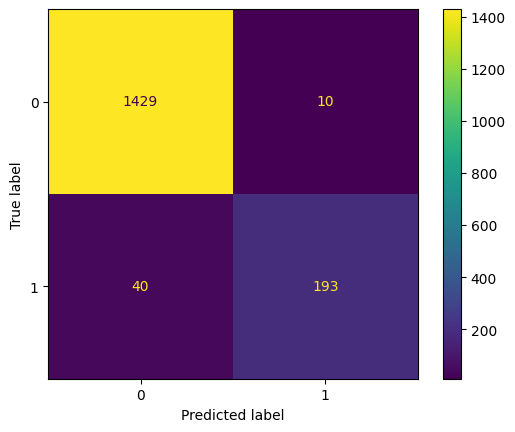

In [9]:
# check performance of classifier
y_pred = text_clf.predict(X_test)
print(compute_risks(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(text_clf, X_test, y_test)

### Risk Control

To control the risks, we use a decision function that depends on the predicted probabilities of the classifier :
- if the model is certain that it is not a spam (ie the score is below `lambda_1`) : predict 'not spam'
- if the model is certain that it is a spam (ie the score is above `lambda_2`) : predict 'spam'
- if the model is uncertain (ie score is between `lambda_1` and `lambda_2`) : abstain

We want to control the abstention rate as well as the postive predictive value (PPV) and negative predictive value (NPV) : **3 risks and 2 parameters**.

In [10]:
def predict_function_with_abstention(X, lambda_1, lambda_2) -> NDArray[np.int_]:
    """Predict function with abstention based on two thresholds.
    - if the score is below `lambda_1`, predict 0 (not spam)
    - if the score is above `lambda_2`, predict 1 (spam)
    - if the score is between `lambda_1` and `lambda_2`, abstain (np.nan)
    """
    y_score = text_clf.predict_proba(X)[:, 1]   # taking the score of the positive class : spam
    y_pred = np.full_like(y_score, np.nan)
    y_pred = np.where(y_score <= lambda_1, 0, y_pred)
    y_pred = np.where(y_score >= lambda_2, 1, y_pred)
    return y_pred

In [11]:
# choose paramaters to explore, enforcing lambda1 <= lambda2 
n_lambdas = 10
lambda_1_values = np.linspace(0.2, 0.8, n_lambdas)
lambda_2_values = np.linspace(0.3, 0.9, n_lambdas)
lambdas_to_explore = []
for lambda_1 in lambda_1_values:
    for lambda_2 in lambda_2_values:
        if lambda_2 >= lambda_1:
            lambdas_to_explore.append((lambda_1, lambda_2))
lambdas_to_explore = np.array(lambdas_to_explore)

In [12]:
# controlling 3 risks (ppv, npv and abstention rate) with two thresholds as defined in the predict_function
target_ppv = 0.9
target_npv = 0.8
target_abstention_rate = 0.1
confidence_level = 0.99

bcc = BinaryClassificationController(
    predict_function=predict_function_with_abstention,
    risk=["positive_predictive_value", "negative_predictive_value", "abstention_rate"],
    target_level=[
        target_ppv,
        target_npv,
        target_abstention_rate,
    ],
    confidence_level=confidence_level,
    best_predict_param_choice="abstention_rate",
    list_predict_params=lambdas_to_explore,
)
bcc.calibrate(X_calib, y_calib)

In [13]:
print(
    f"{len(bcc.valid_predict_params)} two-dimensional parameters found that guarantee with a confidence of {confidence_level}:\n"
    f"- negative predictive value of at least {target_npv} for predicting not spam,\n"
    f"- positive predictive value of at least {target_ppv} for predicting spam, and\n"
    f"- an abstention rate of at most {target_abstention_rate}.\n\n"
    f"Among these, the best thresholds that minimizes the abstention rate are:\n"
    f"- lambda_1 = {bcc.best_predict_param[0]:.2f},\n"
    f"- lambda_2 = {bcc.best_predict_param[1]:.2f}"
)

21 two-dimensional parameters found that guarantee with a confidence of 0.99:
- negative predictive value of at least 0.8 for predicting not spam,
- positive predictive value of at least 0.9 for predicting spam, and
- an abstention rate of at most 0.1.

Among these, the best thresholds that minimizes the abstention rate are:
- lambda_1 = 0.67,
- lambda_2 = 0.70


### Results

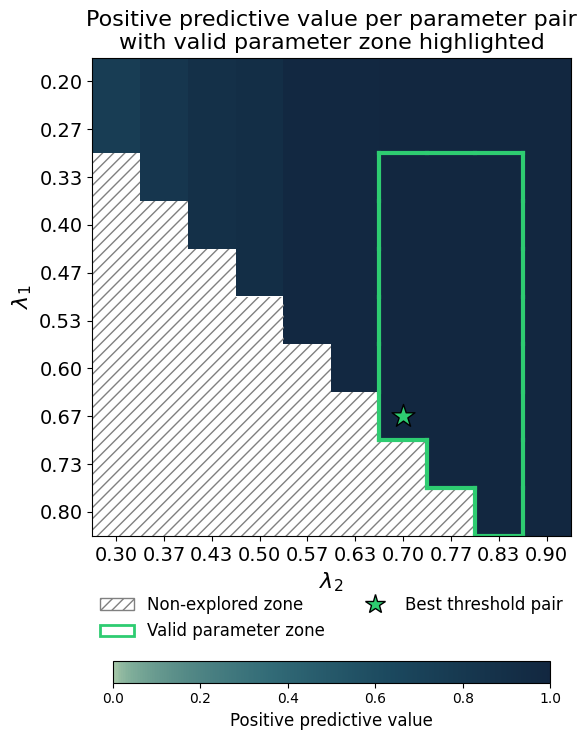

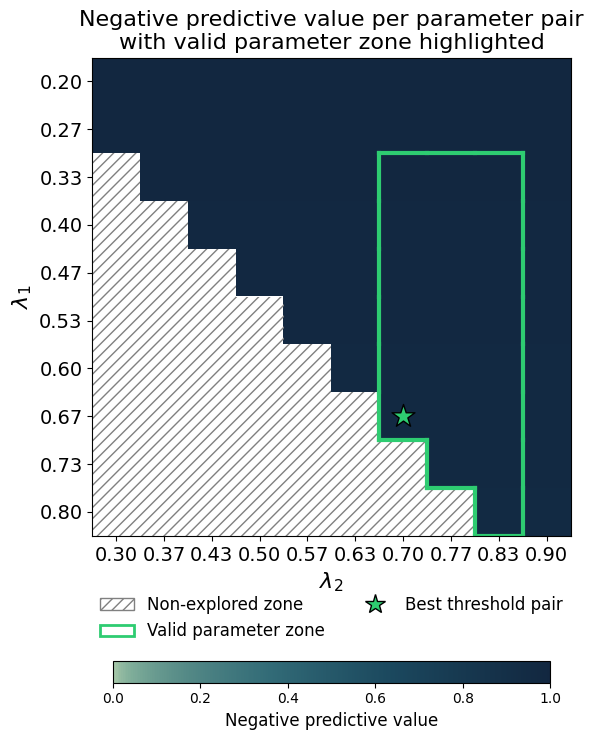

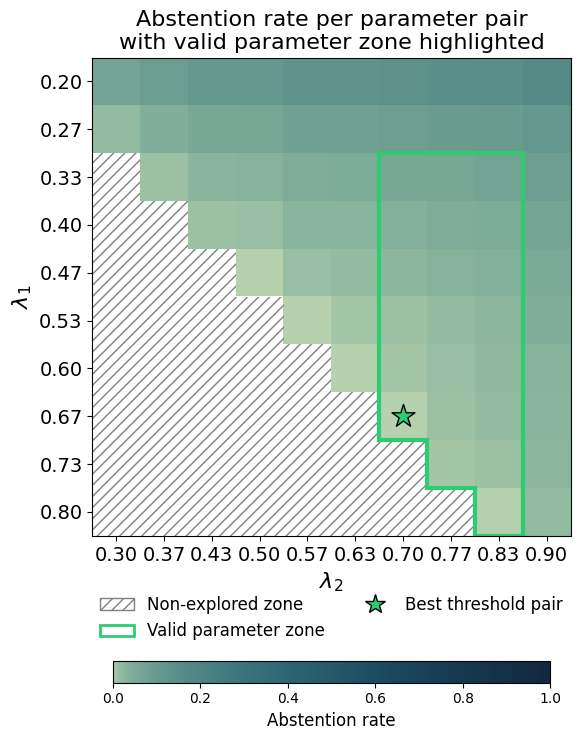

In [14]:
build_plot_risks_matrices(X_calib, y_calib, n_lambdas=n_lambdas, lambdas_to_explore=lambdas_to_explore)

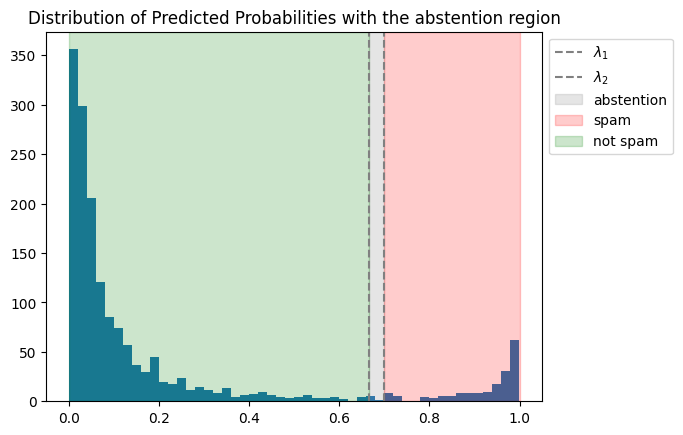

Performance on non abstention region :  {'positive_predictive_value': 0.9884393063583815, 'negative_predictive_value': 0.9605614973262032}


In [15]:
y_proba = text_clf.predict_proba(X_test)
plt.hist(y_proba[:, 1], bins=50)
plt.axvline(bcc.best_predict_param[0], ls='--', color='grey', label=r"$\lambda_1$")
plt.axvline(bcc.best_predict_param[1], ls='--', color='grey', label=r"$\lambda_2$")
plt.axvspan(
    bcc.best_predict_param[0],
    bcc.best_predict_param[1],
    color='grey',
    alpha=0.2,
    label='abstention'
)
plt.axvspan(
    bcc.best_predict_param[1],
    1.0,
    color='red',
    alpha=0.2,
    label='spam'
)
plt.axvspan(
    0.0,
    bcc.best_predict_param[0],
    color='green',
    alpha=0.2,
    label='not spam'
)
plt.title("Distribution of Predicted Probabilities with the abstention region")
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()


y_pred_test_controlled = predict_function_with_abstention(X_test, bcc.best_predict_param[0], bcc.best_predict_param[1])
print("Performance on non abstention region : ", compute_risks(y_test, y_pred_test_controlled))

## Classifier : Pool of LLMs

### Data load

We used the dataset [SMS spam collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) and asked 5 LLMs to classify each SMS as 'spam' or 'not spam'. We saved their answers, the most chosen answer and a score *(0 if all LLMs classified the SMS as 'not spam' and 1 if all LLMs classified it as 'spam')*.

In [16]:
llm_spam_data = pd.read_csv('../data/sms_spam_llm.csv')

X = llm_spam_data["sms"]
y = llm_spam_data[["llms_prediction", "label", "score"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.3, random_state=RANDOM_STATE)

# structure data
X_train = X_train.values.ravel()
X_test = X_test.values.ravel()
X_calib = X_calib.values.ravel()

y_train_llms_pred = transform_y(y_train.llms_prediction)
y_train_true = transform_y(y_train.label)
y_calib_llms_pred = transform_y(y_calib.llms_prediction)
y_calib_true = transform_y(y_calib.label)
y_test_llms_pred = transform_y(y_test.llms_prediction)
y_test_true = transform_y(y_test.label)

# create labels "LLM right" = 1 and "LLM wrong" = 0 to train the surrogate model
label_surrogate_train = np.where(y_train_llms_pred == y_train_true, 1, 0)
label_surrogate_calib = np.where(y_calib_llms_pred == y_calib_true, 1, 0)
label_surrogate_test = np.where(y_test_llms_pred == y_test_true, 1, 0)

y_train_score = y_train.score
y_calib_score = y_calib.score
y_test_score = y_test.score

In [17]:
llm_spam_data.head()

,sms,label,llm1,llm2,llm3,llm4,llm5,llms_prediction,score
0,Ok lar... Joking wif u oni...,not spam,not spam,spam,not spam,spam,not spam,not spam,0.4
1,Free entry in 2 a wkly comp to win FA Cup fina...,spam,spam,spam,spam,spam,spam,spam,1.0
2,"Nah I don't think he goes to usf, he lives aro...",not spam,not spam,not spam,not spam,not spam,not spam,not spam,0.0
3,FreeMsg Hey there darling it's been 3 week's n...,spam,spam,spam,spam,spam,spam,spam,1.0
4,As per your request 'Melle Melle (Oru Minnamin...,not spam,spam,spam,not spam,not spam,spam,spam,0.6


{'positive_predictive_value': 0.717687074829932, 'negative_predictive_value': 0.9933774834437086}


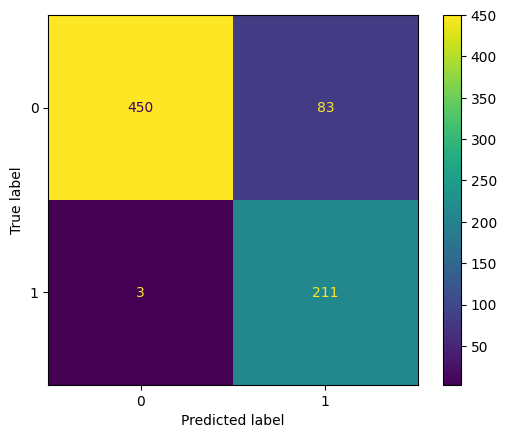

In [18]:
# check performance of LLMs
cm = confusion_matrix(y_test_true, y_test_llms_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

print(compute_risks(y_test_true, y_test_llms_pred))

### 1. Surrogate model

We are training a surrogate model to predict if the LLM is right or wrong. This model takes as input the embedded SMS.

To control the risks, we use a decision function that depends on the score (predict_proba) of this model:
- if we're certain that the pool of LLMs is right (= surrogate model's score > threshold) : we use the LLMs prediction to classify the SMS as spam or not spam
- if not (= surrogate model's score < threshold) : we abstain

We want to control the abstention rate as well as the postive predictive value (PPV) and negative predictive value (NPV) : **3 risks and 1 parameter**.

In [19]:
# loading a simple embedding model and encoding X
embedding_model = SentenceTransformer("sentence-transformers/all-distilroberta-v1")   

X_train_embeddings = embedding_model.encode(X_train)
X_calib_embeddings = embedding_model.encode(X_calib)
X_test_embeddings = embedding_model.encode(X_test)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [20]:
surrogate_model = make_pipeline(
                    StandardScaler(), 
                    SVC()
)

surrogate_model.fit(X_train_embeddings, label_surrogate_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,768
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


{'positive_predictive_value': 0.8956639566395664, 'negative_predictive_value': 1.0}


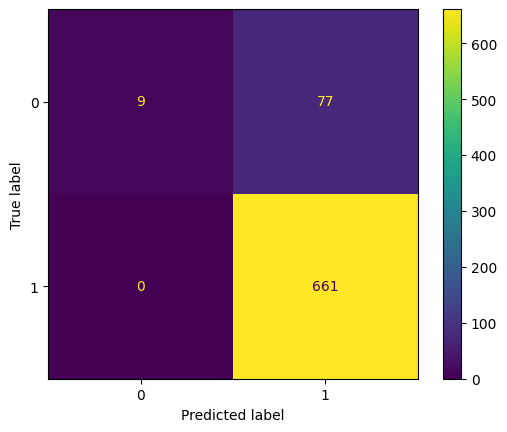

In [21]:
# check performance of classifier
ConfusionMatrixDisplay.from_estimator(surrogate_model, X_test_embeddings, label_surrogate_test)

y_pred_test = surrogate_model.predict(X_test_embeddings)
print(compute_risks(label_surrogate_test, y_pred_test))

#### Risk control with surrogate model

In [22]:
def predict_function_with_abstention(X, lambda1) -> NDArray[np.int_]:
    """Predict function with abstention based on one threshold.
    - if the score of the surrogate model is below `lambda1`, we abstain (np.nan)
    - if the score is above `lambda1`, we use the LLM to predict spam or not spam
    """
    y_score = surrogate_model.decision_function(X)
    y_score = minmax_scale(y_score, feature_range=(-1, 1))
    y_pred = np.where(y_score >= lambda1, y_calib_llms_pred, np.nan)
    return y_pred

In [23]:
# controlling 3 risks (ppv, npv and abstention rate) with one threshold as defined in the predict_function
target_ppv = 0.8   
target_npv = 0.8 
target_abstention_rate = 0.25
confidence_level = 0.9
lambda1_values = np.expand_dims(np.linspace(-0.9, 0.9, 100), axis=1)

bcc = BinaryClassificationController(
    predict_function=predict_function_with_abstention,
    risk=["positive_predictive_value", "negative_predictive_value", "abstention_rate"], 
    target_level=[
        target_ppv,
        target_npv,
        target_abstention_rate,
    ],
    confidence_level=confidence_level,
    best_predict_param_choice="abstention_rate",
    list_predict_params=lambda1_values,
)
bcc.calibrate(X_calib_embeddings, y_calib_true)

In [24]:
print(
    f"{len(bcc.valid_predict_params)} parameters found that guarantee with a confidence of {confidence_level}:\n"
    f"- negative predictive value of at least {target_npv} for predicting not spam,\n"
    f"- positive predictive value of at least {target_ppv} for predicting spam, and\n"
    f"- an abstention rate of at most {target_abstention_rate}.\n\n"
    f"Among these, the best thresholds that minimizes the abstention rate are:\n"
    f"- lambda_1 = {bcc.best_predict_param[0]:.2f},\n"
)

1 parameters found that guarantee with a confidence of 0.9:
- negative predictive value of at least 0.8 for predicting not spam,
- positive predictive value of at least 0.8 for predicting spam, and
- an abstention rate of at most 0.25.

Among these, the best thresholds that minimizes the abstention rate are:
- lambda_1 = 0.10,



#### Results

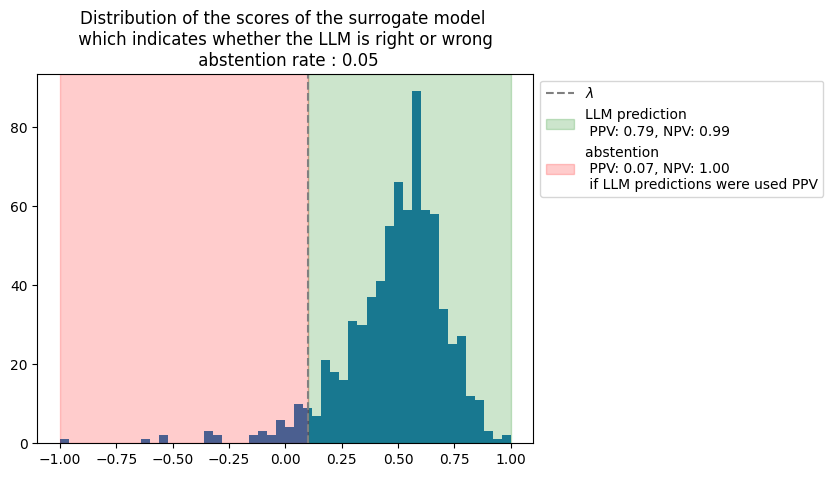

In [25]:
scores_surrogate = surrogate_model.decision_function(X_test_embeddings)
scores_surrogate = minmax_scale(scores_surrogate, feature_range=(-1, 1))

valid_ix = []
not_valid_ix = []
for i in range(len(scores_surrogate)):
    if scores_surrogate[i] > bcc.best_predict_param[0]:
        valid_ix.append(i)
    else:
        not_valid_ix.append(i)

valid_risks = compute_risks(y_test_true[valid_ix], y_test_llms_pred[valid_ix])
not_valid_risks = compute_risks(y_test_true[not_valid_ix], y_test_llms_pred[not_valid_ix])

abstention_rate = len(not_valid_ix)/len(scores_surrogate)

plt.hist(scores_surrogate, bins=50)
plt.axvline(bcc.best_predict_param[0], ls='--', color='grey', label=r"$\lambda$")

plt.axvspan(
    bcc.best_predict_param[0],
    1.0,
    color='green',
    alpha=0.2,
    label=f'LLM prediction \n PPV: {valid_risks["positive_predictive_value"]:.2f}, NPV: {valid_risks["negative_predictive_value"]:.2f}'
)
plt.axvspan(
    -1.0,
    bcc.best_predict_param[0],
    color='red',
    alpha=0.2,
    label=f'abstention \n PPV: {not_valid_risks["positive_predictive_value"]:.2f}, NPV: {not_valid_risks["negative_predictive_value"]:.2f} \n if LLM predictions were used PPV'
)
plt.title(f"Distribution of the scores of the surrogate model \n which indicates whether the LLM is right or wrong \n abstention rate : {abstention_rate:.2f}")
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

*Note: The NPV stays really high because the dataset is imbalanced and the majority of inputs are not spam, so it's not on the 'not spam' class that the model is wrong*

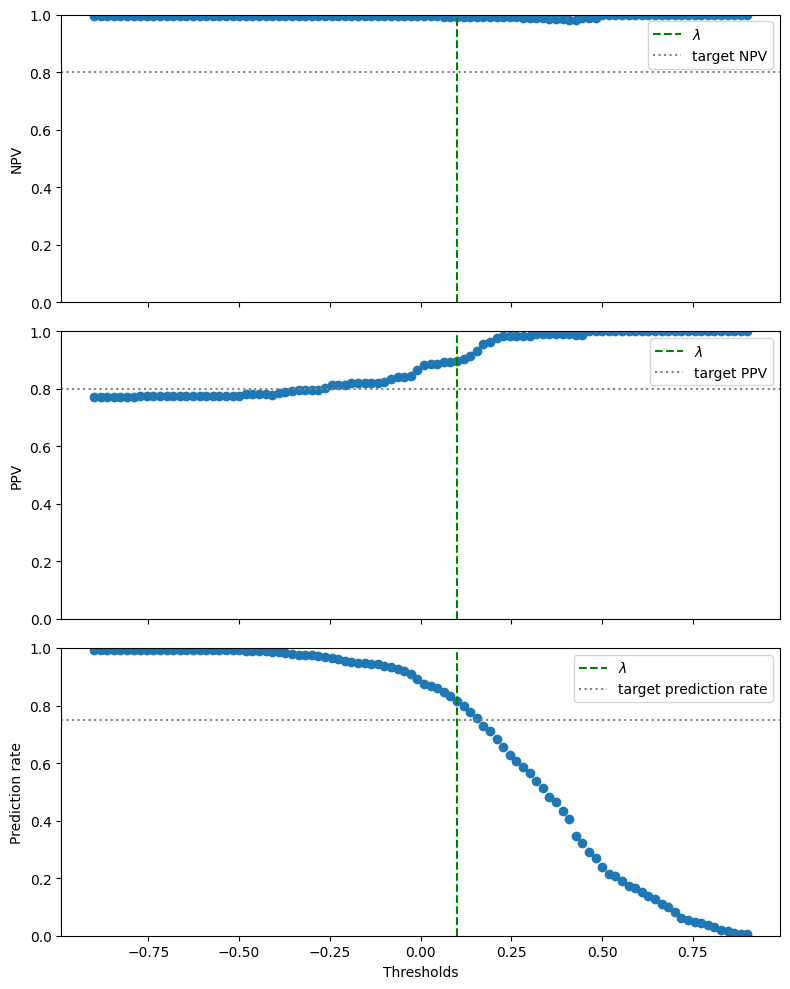

In [26]:
ppv_values = np.full(lambda1_values.shape, np.nan)
npv_values = np.full(lambda1_values.shape, np.nan)
prediction_rate_values = np.full(lambda1_values.shape, np.nan)

for i, l in enumerate(lambda1_values):
    y_pred = predict_function_with_abstention(X_calib_embeddings, l)
    non_abstention_ix = np.argwhere(~np.isnan(y_pred))
    ppv_values[i] = precision_score(y_calib_true[non_abstention_ix], y_pred[non_abstention_ix])   # ppv equivalent
    npv_values[i] = precision_score(y_calib_true[non_abstention_ix], y_pred[non_abstention_ix], pos_label=0)  # npv equivalent
    prediction_rate_values[i] = 1 - np.count_nonzero(np.isnan(y_pred))/y_pred.shape[0]   # abstention_rate


fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].scatter(lambda1_values, npv_values)
axes[0].set_ylim(0, 1)
axes[0].axvline(bcc.best_predict_param[0], color="green", linestyle="--", label=r"$\lambda$")
axes[0].axhline(target_npv, color="grey", linestyle=":", label=f"target NPV")
axes[0].set_ylabel("NPV")
axes[0].legend()

axes[1].scatter(lambda1_values, ppv_values)
axes[1].set_ylim(0, 1)
axes[1].axvline(bcc.best_predict_param[0], color="green", linestyle="--", label=r"$\lambda$")
axes[1].axhline(target_ppv, color="grey", linestyle=":", label=f"target PPV")
axes[1].set_ylabel("PPV")
axes[1].legend()

axes[2].scatter(lambda1_values, prediction_rate_values)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Prediction rate")
axes[2].axvline(bcc.best_predict_param[0], color="green", linestyle="--", label=r"$\lambda$")
axes[2].axhline(1 - target_abstention_rate, color="grey", linestyle=":", label=f"target prediction rate")
axes[2].set_xlabel("Thresholds")
axes[2].legend()

plt.tight_layout()
plt.show()

### 2. Score of LLMs pool : risk control

We computed a score between 0 and 1 over the answers of the pool of LLMs : 0 if all LLMs classified the SMS as 'not spam' and 1 if all LLMs classified it as 'spam'.

To control the risks, we use a decision function that depends on that score:
- if the LLMs are certain that it is not a spam (ie the score is below `lambda_1`) : predict 'not spam'
- if the LLMs are certain that it is a spam (ie the score is above `lambda_2`) : predict 'spam'
- if the LLMs are uncertain (ie score is between `lambda_1` and `lambda_2`) : abstain

We want to control the abstention rate as well as the postive predictive value (PPV) and negative predictive value (NPV) : **3 risks and 2 parameters**.

In [27]:
def predict_function_with_abstention(X, lambda_1, lambda_2) -> NDArray[np.int_]:
    """Predict function with abstention based on two thresholds.
    - if the score is below `lambda_1`, predict 0 (not spam)
    - if the score is above `lambda_2`, predict 1 (spam)
    - if the score is between `lambda_1` and `lambda_2`, abstain (np.nan)
    """
    # taking the score of the positive class : spam
    y_pred = np.full_like(y_calib_score, np.nan)
    y_pred = np.where(y_calib_score < lambda_1, 0, y_pred)
    y_pred = np.where(y_calib_score > lambda_2, 1, y_pred)
    return y_pred

In [28]:
# choose paramaters to explore, enforcing lambda1 <= lambda2
n_lambdas = 10
lambda_1_values = np.linspace(0.1, 0.8, n_lambdas)
lambda_2_values = np.linspace(0.2, 0.9, n_lambdas)
lambdas_to_explore = []
for lambda_1 in lambda_1_values:
    for lambda_2 in lambda_2_values:
        if lambda_2 >= lambda_1:
            lambdas_to_explore.append((lambda_1, lambda_2))
lambdas_to_explore = np.array(lambdas_to_explore)

In [29]:
# controlling 3 risks (ppv, npv and abstention rate) with one threshold as defined in the predict_function
target_ppv = 0.8
target_npv = 0.8
target_abstention_rate = 0.1
confidence_level = 0.95

bcc = BinaryClassificationController(
    predict_function=predict_function_with_abstention,
    risk=["positive_predictive_value", "negative_predictive_value", "abstention_rate"], 
    target_level=[
        target_ppv,
        target_npv,
        target_abstention_rate,
    ],
    confidence_level=confidence_level,
    best_predict_param_choice="abstention_rate",
    list_predict_params=lambdas_to_explore
)
bcc.calibrate(X_calib, y_calib_true)

In [30]:
print(
    f"{len(bcc.valid_predict_params)} two-dimensional parameters found that guarantee with a confidence of {confidence_level}:\n"
    f"- negative predictive value of at least {target_npv} for predicting not spam,\n"
    f"- positive predictive value of at least {target_ppv} for predicting spam, and\n"
    f"- an abstention rate of at most {target_abstention_rate}.\n\n"
)
print(
    f"Among these, the best thresholds that minimizes the abstention rate are:\n"
    f"- lambda_1 = {bcc.best_predict_param[0]:.2f},\n"
    f"- lambda_2 = {bcc.best_predict_param[1]:.2f}"
)

6 two-dimensional parameters found that guarantee with a confidence of 0.95:
- negative predictive value of at least 0.8 for predicting not spam,
- positive predictive value of at least 0.8 for predicting spam, and
- an abstention rate of at most 0.1.


Among these, the best thresholds that minimizes the abstention rate are:
- lambda_1 = 0.64,
- lambda_2 = 0.82


#### Results

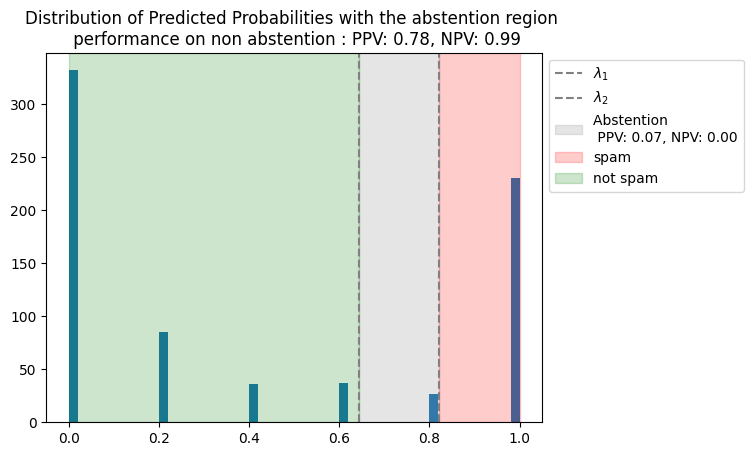

In [31]:
scores = y_test_score.values

valid_ix = []
not_valid_ix = []
for i in range(len(scores)):
    if scores[i] >= bcc.best_predict_param[0] and scores[i] <= bcc.best_predict_param[1]:
        not_valid_ix.append(i)
    else:
        valid_ix.append(i)

valid_risks = compute_risks(y_test_true[valid_ix], y_test_llms_pred[valid_ix])
not_valid_risks = compute_risks(y_test_true[not_valid_ix], y_test_llms_pred[not_valid_ix])

abstention_rate = len(not_valid_ix)/len(scores_surrogate)

plt.hist(y_test_score, bins=50)
plt.axvline(bcc.best_predict_param[0], ls='--', color='grey', label=r"$\lambda_1$")
plt.axvline(bcc.best_predict_param[1], ls='--', color='grey', label=r"$\lambda_2$")
plt.axvspan(
    bcc.best_predict_param[0],
    bcc.best_predict_param[1],
    color='grey',
    alpha=0.2,
    label=f'Abstention \n PPV: {not_valid_risks["positive_predictive_value"]:.2f}, NPV: {not_valid_risks["negative_predictive_value"]:.2f}'
)
plt.axvspan(
    bcc.best_predict_param[1],
    1.0,
    color='red',
    alpha=0.2,
    label='spam'
)
plt.axvspan(
    0.0,
    bcc.best_predict_param[0],
    color='green',
    alpha=0.2,
    label='not spam'
)
plt.title(f"Distribution of Predicted Probabilities with the abstention region \n performance on non abstention : PPV: {valid_risks["positive_predictive_value"]:.2f}, NPV: {valid_risks["negative_predictive_value"]:.2f}")
plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

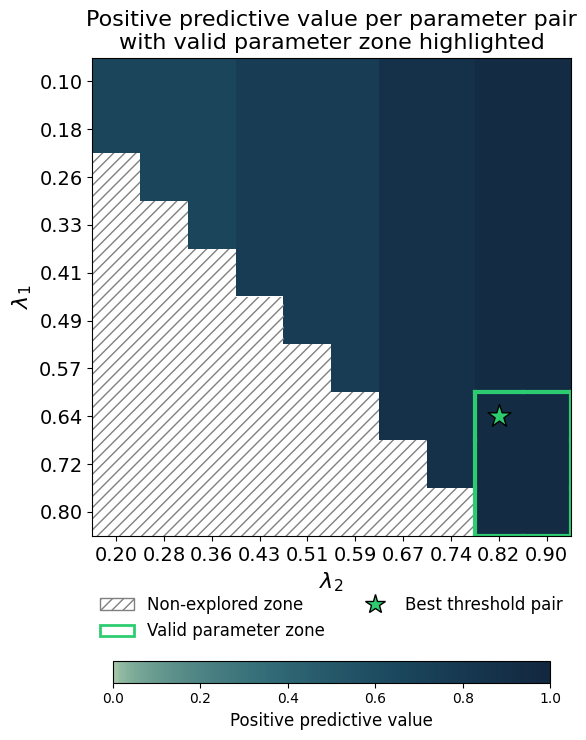

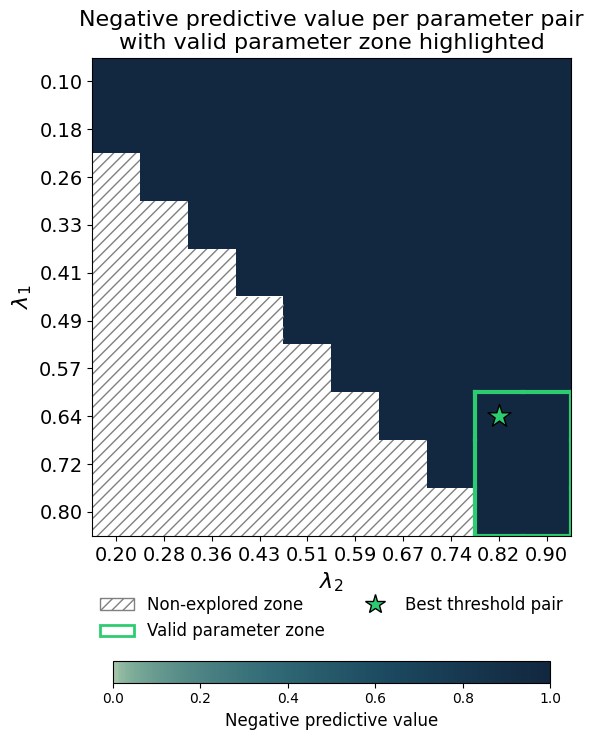

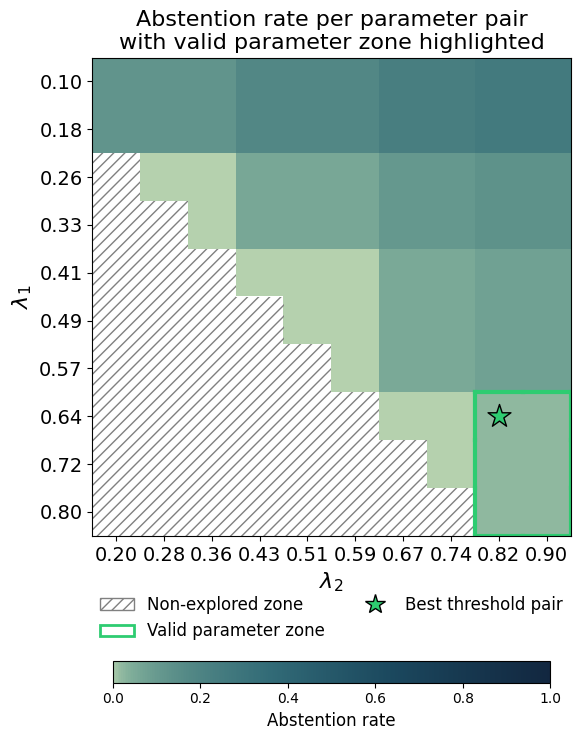

In [32]:
build_plot_risks_matrices(X_calib, y_calib_true, n_lambdas=n_lambdas, lambdas_to_explore=lambdas_to_explore)